# Feature Engineering

The following tutorial contains examples of Python code for feature engineering. 
You should refer to the "Feature Engineering" Lecture Note in Week 4.
Reference links to the scikit-learn documentation are provided for a more comprehensive learning experience.

In this tutorial, you will learn how to:

- Conduct univariate feature selection algorithm.
- Understand the Gini Index and Information Gain for evaluating feature importance.

- Conduct recursive feature elimination algorithm.

- Conduct PCA feature reduction algorithm.




> **Note:** Execute code cells with `Shift+Enter`.


## 1.0 Univariate Feature Selection

Univariate feature selection works by selecting the best features based on univariate statistical tests. It can be seen as a preprocessing step to an estimator.

**Key reference:**
- [SelectKBest – scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html)
- [Feature selection – scikit-learn user guide](https://scikit-learn.org/stable/modules/feature_selection.html#univariate-feature-selection)

The following code identify the algorithm SelectKBest from sklearn library.

In [1]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif,chi2,f_regression
# f_classif: ANOVA F-value between label/feature for classification tasks.
# chi2: Chi-squared stats of non-negative features for classification tasks.
# f_regression F-value between label/feature for regression tasks.
import pandas as pd

/Users/liujunming/.conda/envs/Substitution/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### 1.1 Load your Raw Data

Recall the iris dataset has four features and one class:

- feature 1: sepal length in centimeters
- feature 2: sepal width in centimeters
- feature 3: petal length in centimeters
- feature 4: petal width in centimeters
- class (Setosa, Versicolour, Virginica)



In [2]:
iris = pd.read_csv('iris.txt', header=None)
iris.columns = ['sepal-L', 'sepal-W', 'petal-L', 'petal-W', 'class']
iris  # you get a dataset of 150 objects and 4 features

,sepal-L,sepal-W,petal-L,petal-W,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


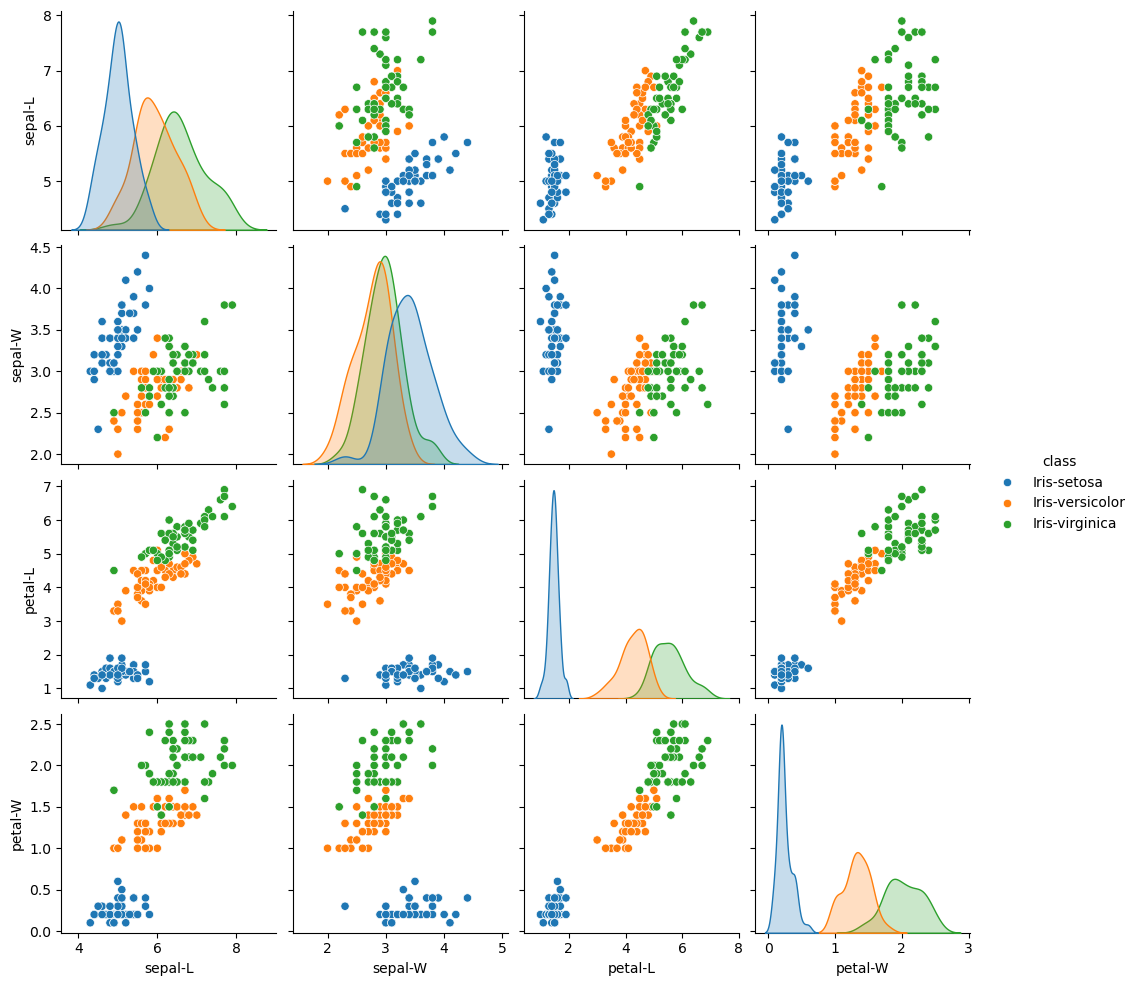

In [3]:
import seaborn as sns #let's take a look at the pairwise plot
sns.pairplot(iris, hue="class") #which features are most representative?

### 1.2 Identify your features and target


In [4]:
features = ['sepal-L', 'sepal-W', 'petal-L', 'petal-W']
target = ['class']
X = iris[features]
y = iris[target]
display(X)

,sepal-L,sepal-W,petal-L,petal-W
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


### 1.3 Select the TWO most representative features from the 4 features using measurement Chi2

The `SelectKBest` is the algorithm you pick from the library.

The `chi2` is the measurement; you can change it to `f_classif` (ANOVA F-value). 

The `k=2` is the number of optimal features you select from the complete set.

**Reference:**
- [SelectKBest – scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html)
- [chi2 – scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.chi2.html)
- [f_classif – scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_classif.html)


In [5]:
X_new = SelectKBest(chi2, k=2).fit_transform(X, y)  # we use chi2 as the criteria and select k=2 best features
X_new.shape  # you get a new feature set of dimension k=2

(150, 2)

### 1.4 Check the selected features


In [6]:
display(X_new[0:5, :])  # petal-L and petal-W were selected

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

### 1.5 Feature importance: Gini Index & Information Gain


1. **Gini Index (GINI_split)**: We want to **Minimize** this weighted impurity.
   - $GINI_{split} = \sum_{i=1}^{k} \frac{n_i}{n} GINI(i)$
2. **Information Gain (GAIN_split)**: We want to **Maximize** this entropy reduction.
   - $GAIN_{split} = Entropy(p) - \left( \sum_{i=1}^{k} \frac{n_i}{n} Entropy(i) \right)$

We will evaluate the two PPT cases:
- **Case 1:** `Petal-W <= 0.8` (Perfect split)
- **Case 2:** `Sepal-L <= 6.0` (Imperfect split from the in-class quiz)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Load Data
iris_filter = pd.read_csv('iris.txt', header=None)
iris_filter.columns = ['sepal-L', 'sepal-W', 'petal-L', 'petal-W', 'class']

# 2. Create a binary target (Setosa vs Non-Setosa) for this specific quiz question
iris_filter['is_setosa'] = (iris_filter['class'] == 'Iris-setosa').astype(int)

# 3. Define Impurity Functions
def calc_gini(y):
    """Calculate Gini Index for a given subset of labels."""
    p = y.value_counts(normalize=True)
    return 1 - np.sum(p ** 2)

def calc_entropy(y):
    """Calculate Entropy for a given subset of labels."""
    p = y.value_counts(normalize=True)
    return -np.sum(p * np.log2(p + 1e-12))

# 4. Define Split Evaluation Function
def evaluate_split(df, feature, threshold, target='is_setosa'):
    # Split the data
    left = df[df[feature] <= threshold]
    right = df[df[feature] > threshold]
    n = len(df)
    n_left, n_right = len(left), len(right)

    # Parent Node Impurity
    parent_gini = calc_gini(df[target])
    parent_entropy = calc_entropy(df[target])

    # Child Node Impurities
    gini_left = calc_gini(left[target]) if n_left else 0
    gini_right = calc_gini(right[target]) if n_right else 0
    
    entropy_left = calc_entropy(left[target]) if n_left else 0
    entropy_right = calc_entropy(right[target]) if n_right else 0

    # Weighted Impurity (GINI_split) - Lower is better
    gini_split = (n_left / n) * gini_left + (n_right / n) * gini_right

    # Information Gain (GAIN_split) - Higher is better
    gain_split = parent_entropy - ((n_left / n) * entropy_left + (n_right / n) * entropy_right)

    return {
        'Feature': feature,
        'Threshold': threshold,
        'n_left': n_left,
        'n_right': n_right,
        'Parent_Gini': round(parent_gini, 4),
        'GINI_split': round(gini_split, 4), # Want to minimize
        'Parent_Entropy': round(parent_entropy, 4),
        'GAIN_split': round(gain_split, 4)   # Want to maximize
    }

# 5. Evaluate the Two PPT Cases
results = pd.DataFrame([
    evaluate_split(iris_filter, 'petal-W', 0.8),
    evaluate_split(iris_filter, 'sepal-L', 6.0)
])

# 6. Display Results
display(results)

,Feature,Threshold,n_left,n_right,Parent_Gini,GINI_split,Parent_Entropy,GAIN_split
0,petal-W,0.8,50,100,0.4444,0.0000,0.9183,0.9183
1,sepal-L,6.0,89,61,0.4444,0.2921,0.9183,0.3315


###  Visualize the two splits to understand "Perfect" vs "Imperfect"


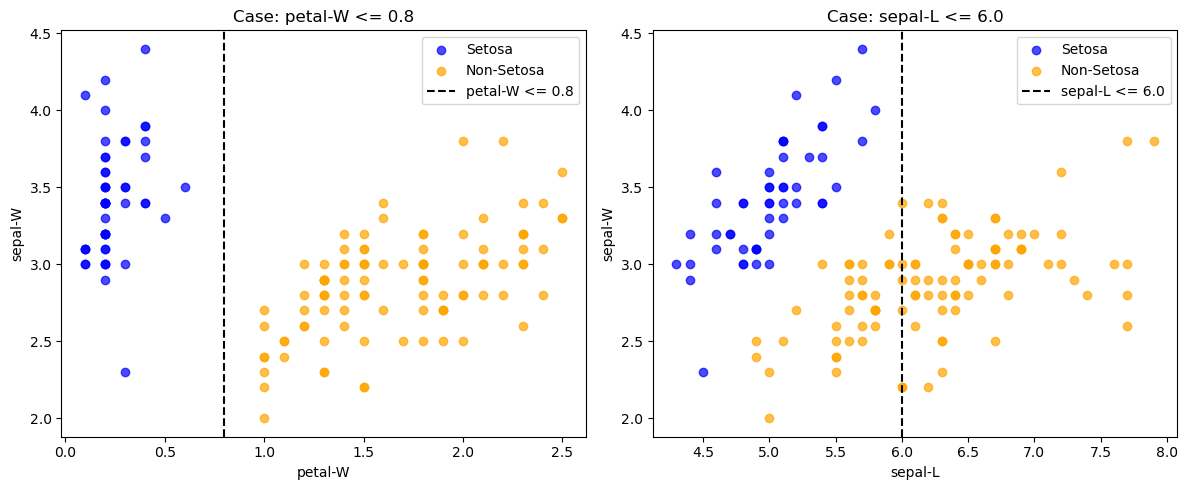

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (feature, threshold) in zip(axes, [('petal-W', 0.8), ('sepal-L', 6.0)]):
    # Plot Setosa
    setosa = iris_filter[iris_filter['is_setosa'] == 1]
    non_setosa = iris_filter[iris_filter['is_setosa'] == 0]
    
    ax.scatter(setosa[feature], setosa['sepal-W'], color='blue', label='Setosa', alpha=0.7)
    ax.scatter(non_setosa[feature], non_setosa['sepal-W'], color='orange', label='Non-Setosa', alpha=0.7)
    
    # Draw threshold line
    ax.axvline(threshold, color='black', linestyle='--', label=f'{feature} <= {threshold}')
    
    ax.set_xlabel(feature)
    ax.set_ylabel('sepal-W')
    ax.set_title(f'Case: {feature} <= {threshold}')
    ax.legend()

plt.tight_layout()
plt.show()

### Interpretation of Results

Based on the table and plots above, we can confirm the lecture's conclusions:

1. **Case 1: `Petal-W <= 0.8` (Perfect Split)**
   - **GINI_split** is extremely low (close to 0).
   - **GAIN_split** is very high.
   - *Reason*: This threshold perfectly isolates the Setosa class. The left node contains almost entirely Setosa, and the right node contains almost entirely Non-Setosa. The weighted impurity is minimized, and information gain is maximized.

2. **Case 2: `Sepal-L <= 6.0` (Imperfect Split)**
   - **GINI_split** is higher.
   - **GAIN_split** is lower.
   - *Reason*: This threshold splits the data, but both the left and right nodes contain a mix of Setosa and Non-Setosa. Because the child nodes are not pure, the weighted impurity is higher, and the reduction in entropy (Information Gain) is lower.


## 2. Feature Selection — use Wrapper model to measure feature importance

The `SelectFromModel` from the sklearn library is a kind of Wrapper model. The algorithm selected for feature importance measurement is `ExtraTreesClassifier`.

**Reference:**
- [SelectFromModel – scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html)
- [ExtraTreesClassifier – scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html)


In [9]:
from sklearn.ensemble import ExtraTreesClassifier
#This class implements a meta estimator that fits a number of randomized decision trees 
#(a.k.a. extra-trees) on various sub-samples of the dataset and 
#uses averaging to improve the predictive accuracy and control over-fitting.

from sklearn.feature_selection import SelectFromModel


### 2.1 We will generate the dataset

In [10]:
iris = pd.read_csv('iris.txt',header=None)
iris.columns=['sepal-L','sepal-W','petal-L','petal-W','class']
features=['sepal-L','sepal-W','petal-L','petal-W']
target=['class']
X=iris[features]
y=iris[target]
X=X.values
y=y.values.ravel()  #please note y is a one-dimensional data, we need to use ravel() to reshape it to (n,) 

In [11]:
y.shape

(150,)

### 2.2 We identify a classifier and use the classifier to measure feature importance



In [12]:
clf = ExtraTreesClassifier(n_estimators=50)  # get the model from library
clf = clf.fit(X, y)  # fit your data
clf.feature_importances_  # now we can get the feature importance score from model

array([0.07130379, 0.05632203, 0.38856605, 0.48380814])

### 2.3 Select your feature subset from SelectFromModel

Reference: <https://scikit-learn.org/stable/modules/feature_selection.html#select-from-model>


In [13]:
selection = SelectFromModel(clf, prefit=True)
X_new = selection.transform(X)
display(X_new[0:5, :])

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

### 2.4 Recursive Feature Elimination (RFE)

Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), recursive feature elimination (RFE) is to select features by recursively considering smaller and smaller sets of features. First, the estimator is trained on the initial set of features and the importance of each feature is obtained either through a `coef_` attribute or through a `feature_importances_` attribute. Then, the least important features are pruned from the current set of features. That procedure is recursively repeated on the pruned set until the desired number of features to select is eventually reached.

**Reference:**
- [RFE – scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html)


In [14]:
from sklearn.feature_selection import RFE
clf = ExtraTreesClassifier(n_estimators=50)
selection = RFE(estimator=clf, n_features_to_select=2, step=1)
selection.fit(X,y)
X_new=selection.transform(X)
display(X_new[0:5,:])

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

In [15]:
# alternatively, put fit and transform together:
X_new = selection.fit_transform(X, y)
display(X_new[0:5, :])

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

## 3. Feature Reduction — Principle Component Analysis (PCA)

Principal Component Analysis (PCA) applied to this data identifies the combination of attributes (principal components, or directions in the feature space) that account for the most variance in the data. Here we plot the different samples on the 2 first principal components.

**Reference:**
- [PCA – scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
- [PCA – scikit-learn user guide](https://scikit-learn.org/stable/modules/decomposition.html#pca)

We first get PCA algorithm from the library and then map the 4-dimensional feature set into a 2-dimensional feature set:

In [16]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

We map it to a two dimensional space

In [17]:
iris = pd.read_csv('iris.txt', header=None)
iris.columns = ['sepal-L', 'sepal-W', 'petal-L', 'petal-W', 'class']
X = iris[['sepal-L', 'sepal-W', 'petal-L', 'petal-W']].values
pca = PCA(n_components=2)  # we select PCA algorithm with 2 dimensions
z = pca.fit(X).transform(X)

In [18]:
display(z[:5, :])

array([[-2.68420713,  0.32660731],
       [-2.71539062, -0.16955685],
       [-2.88981954, -0.13734561],
       [-2.7464372 , -0.31112432],
       [-2.72859298,  0.33392456]])

In [19]:
iris['z1'] = z[:, 0]
iris['z2'] = z[:, 1]
iris.head()

,sepal-L,sepal-W,petal-L,petal-W,class,z1,z2
0,5.1,3.5,1.4,0.2,Iris-setosa,-2.684207,0.326607
1,4.9,3.0,1.4,0.2,Iris-setosa,-2.715391,-0.169557
2,4.7,3.2,1.3,0.2,Iris-setosa,-2.889820,-0.137346
3,4.6,3.1,1.5,0.2,Iris-setosa,-2.746437,-0.311124
4,5.0,3.6,1.4,0.2,Iris-setosa,-2.728593,0.333925


We scatter plot the data in a the new space of z

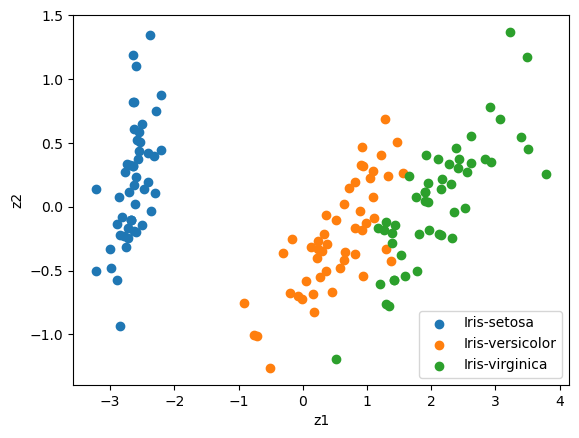

In [20]:
import matplotlib.pyplot as plt
groups = iris.groupby("class")
for name, group in groups:
    plt.scatter(group['z1'],group['z2'], marker="o", label=name)
plt.xlabel('z1')
plt.ylabel('z2')
plt.legend()
plt.show()

---
# Week 4 Assignment



### Question 1
use f_classif as your evaluation measurement and redo the feature selection in Univariate feature selection. what does "f_classif" represent? Is this a filter model or wrapper model? (20 points). 


### Question 2
Read documentation of "SequentialFeatureSelector" and use it to select the top TWO features. What is the mechnism of this tool? What are these two optimal features? (40 points)

document: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html

### Question 3
Load `Airbnb.csv`on Canvas-Week4 Homepage. The target is `log_price` (regression). Use `SelectKBest` with `f_regression` to select the top 8 features. Print the selected feature names. Briefly explain why `chi2` and `f_classif` are not appropriate here. (20 Points)


### Question 4
Load `Airbnb.csv`on Canvas-Week4 Homepage. The target is `log_price` (regression). Use `RandomForestRegressor` with `RFE` to select 8 features. Print the selected feature names. Briefly compare them with your answer in Question 3 and discuss any difference. (20 Points)

document: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor